In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [3]:
#loading the dataset
df=pd.read_csv("UCI_Credit_Card.csv",header=0)
df.rename(columns={'default.payment.next.month':'default'},inplace=True)
df.drop(columns=['ID'],inplace=True)



In [4]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nNull counts:\n", df.isnull().sum())
print("\nClass balance:")
print(df['default'].value_counts())
print(df['default'].value_counts(normalize=True).round(3))

Shape: (30000, 24)

Dtypes:
 LIMIT_BAL    float64
SEX            int64
EDUCATION      int64
MARRIAGE       int64
AGE            int64
PAY_0          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
default        int64
dtype: object

Null counts:
 LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64

Class balance:
default
0    23364
1     6636
Name: count, dtype:

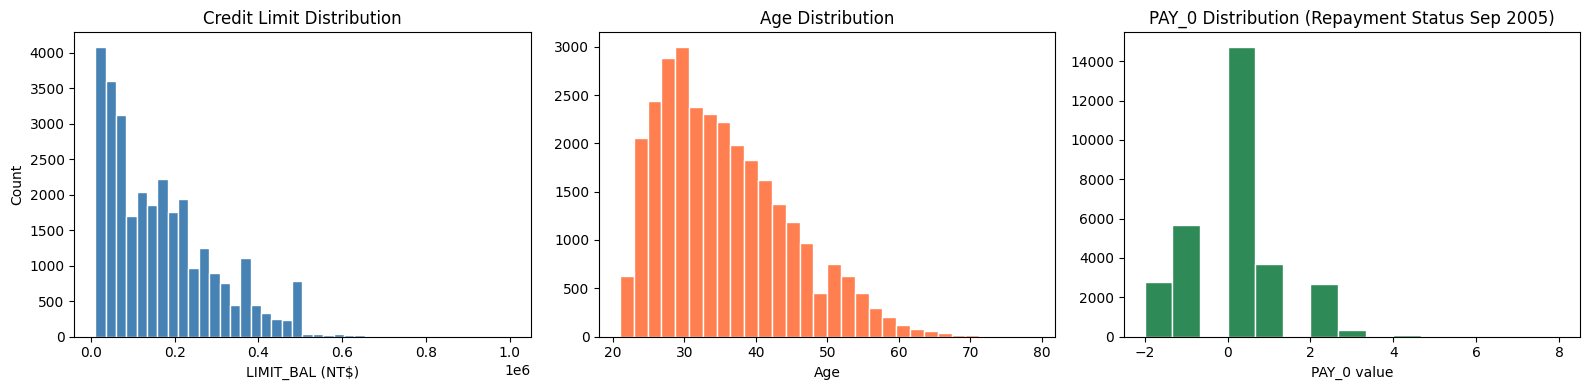

In [5]:
#EDA

fig,axes=plt.subplots(1,3, figsize=(16,4))
axes[0].hist(df['LIMIT_BAL'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Credit Limit Distribution')
axes[0].set_xlabel('LIMIT_BAL (NT$)')
axes[0].set_ylabel('Count')

#AGE distribution
axes[1].hist(df['AGE'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age')

#PAY_0 distribution (most recent repayment status)
axes[2].hist(df['PAY_0'], bins=15, color='seagreen', edgecolor='white')
axes[2].set_title('PAY_0 Distribution (Repayment Status Sep 2005)')
axes[2].set_xlabel('PAY_0 value')

plt.tight_layout()
plt.savefig('distributions.png', dpi=150)
plt.show()

/tmp/ipykernel_5762/467814515.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group=df.groupby('AGE_BAND')['default'].mean()


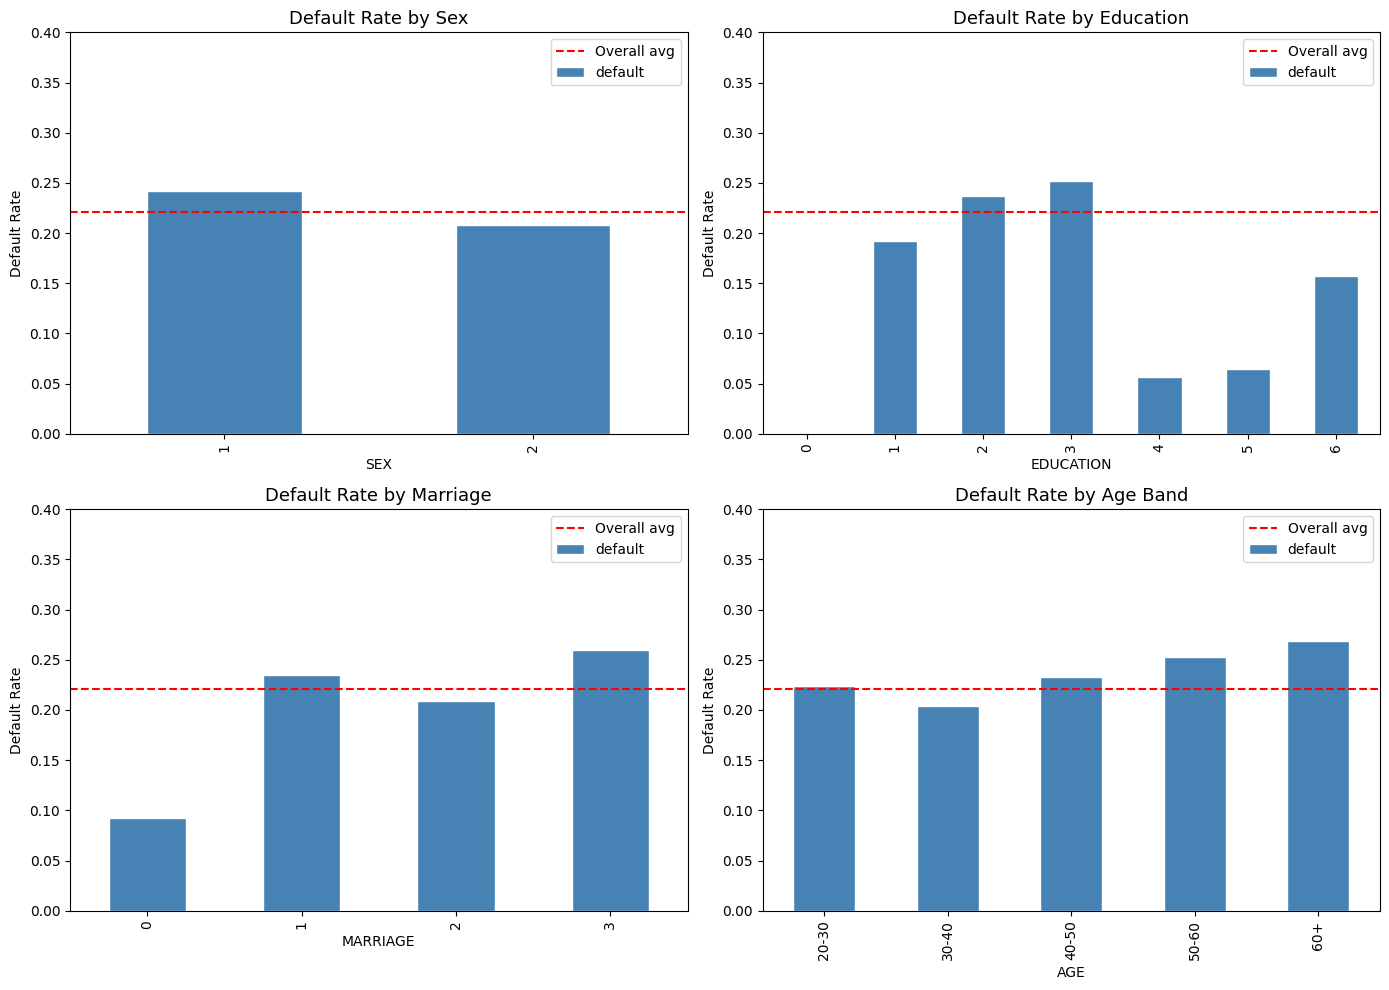

In [6]:
fig, axes=plt.subplots(2, 2, figsize=(14, 10))

for ax,col, title in zip(
    axes.flatten(),
    ['SEX', 'EDUCATION', 'MARRIAGE', 'AGE'],
    ['Default Rate by Sex', 'Default Rate by Education',
     'Default Rate by Marriage', 'Default Rate by Age Band']
):
    if col=='AGE':
        df['AGE_BAND'] = pd.cut(df['AGE'], bins=[20,30,40,50,60,80],
                                 labels=['20-30','30-40','40-50','50-60','60+'])
        group=df.groupby('AGE_BAND')['default'].mean()
    else:
        group=df.groupby(col)['default'].mean()

    group.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Default Rate')
    ax.set_xlabel(col)
    ax.set_ylim(0, 0.4)
    ax.axhline(df['default'].mean(), color='red', linestyle='--', label='Overall avg')
    ax.legend()

plt.tight_layout()
plt.savefig('default_rates_by_group.png', dpi=150)
plt.show()

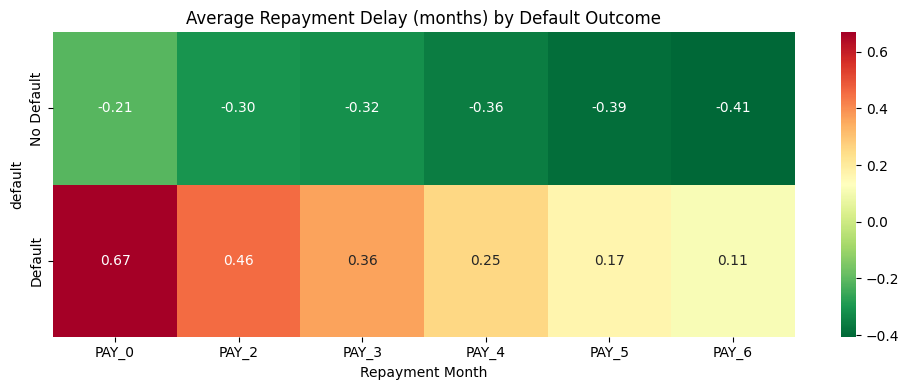

In [7]:
#Repayment Delay Heatmap and correlation
pay_cols=['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

pay_by_default=df.groupby('default')[pay_cols].mean()

plt.figure(figsize=(10, 4))
sns.heatmap(pay_by_default, annot=True, fmt='.2f', cmap='RdYlGn_r',
            yticklabels=['No Default', 'Default'])
plt.title('Average Repayment Delay (months) by Default Outcome')
plt.xlabel('Repayment Month')
plt.tight_layout()
plt.savefig('repayment_heatmap.png', dpi=150)
plt.show()

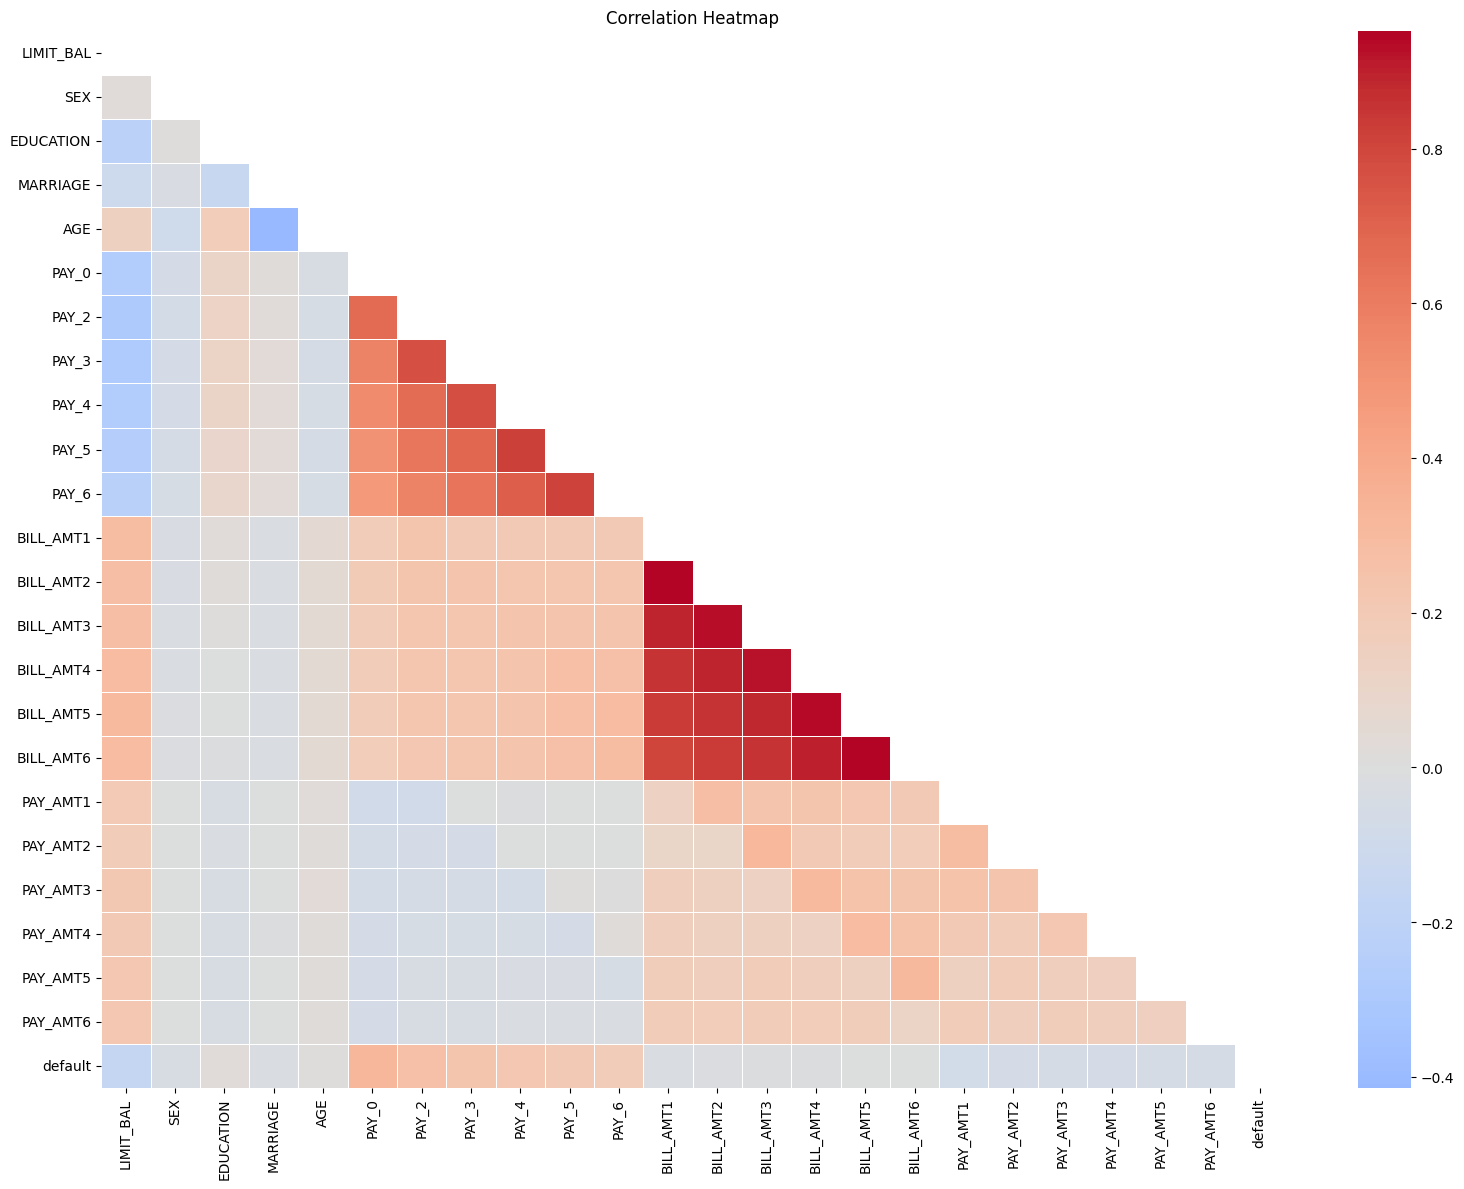

Top 5 features correlated with default:
 PAY_0    0.324794
PAY_2    0.263551
PAY_3    0.235253
PAY_4    0.216614
PAY_5    0.204149
Name: default, dtype: float64


In [8]:
#Correlation Heatmap
plt.figure(figsize=(16, 12))
corr=df.corr(numeric_only=True)
mask=np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

#Top 5 features correlated with default
top5=corr['default'].drop('default').abs().sort_values(ascending=False).head(5)
print("Top 5 features correlated with default:\n", top5)

In [9]:
#Feature Engineering
bill_cols=['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_amt_cols=['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']
pay_status_cols=['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

#AVG_UTIL_RATE
df['AVG_UTIL_RATE']=df[bill_cols].mean(axis=1) / df['LIMIT_BAL']

#AVG_PAY_RATIO
pay_ratios=[]
for i in range(1, 7):
    bill=df[f'BILL_AMT{i}']
    paid=df[f'PAY_AMT{i}']
    ratio=np.where(bill > 0, paid / bill, np.nan)
    pay_ratios.append(ratio)

df['AVG_PAY_RATIO']=np.nanmean(pay_ratios, axis=0)
df['AVG_PAY_RATIO']=df['AVG_PAY_RATIO'].fillna(0)
df['AVG_PAY_RATIO']=df['AVG_PAY_RATIO'].clip(upper=2)

#TOTAL_DELAY_MONTHS
df['TOTAL_DELAY_MONTHS']=(df[pay_status_cols] > 0).sum(axis=1)

#Edge case handling
neg_bill_count=(df[bill_cols] < 0).sum().sum()
print(f"Negative BILL_AMT entries (overpayments): {neg_bill_count}")
df['AVG_UTIL_RATE']=df['AVG_UTIL_RATE'].clip(lower=0)

df['EDUCATION']=df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df['MARRIAGE']=df['MARRIAGE'].replace({0: 3})

print("\nEDUCATION value counts after cleaning:")
print(df['EDUCATION'].value_counts().sort_index())
print("\nMARRIAGE value counts after cleaning:")
print(df['MARRIAGE'].value_counts().sort_index())

print("\nNew features sample:")
print(df[['AVG_UTIL_RATE', 'AVG_PAY_RATIO', 'TOTAL_DELAY_MONTHS']].describe())

Negative BILL_AMT entries (overpayments): 3932

EDUCATION value counts after cleaning:
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

MARRIAGE value counts after cleaning:
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64

New features sample:
       AVG_UTIL_RATE  AVG_PAY_RATIO  TOTAL_DELAY_MONTHS
count   30000.000000   30000.000000        30000.000000
mean        0.373139       0.493608            0.834200
std         0.351781       0.692234            1.554303
min         0.000000       0.000000            0.000000
25%         0.029997       0.039880            0.000000
50%         0.284834       0.077576            0.000000
75%         0.687929       0.838536            1.000000
max         5.364308       2.000000            6.000000


/tmp/ipykernel_5762/2472585742.py:17: RuntimeWarning: Mean of empty slice
  df['AVG_PAY_RATIO']=np.nanmean(pay_ratios, axis=0)


In [10]:
#model Training
#Model Development
drop_cols=['default', 'AGE_BAND']
X=df.drop(columns=drop_cols)
y=df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler=StandardScaler()
X_train_sc=scaler.fit_transform(X_train)
X_test_sc=scaler.transform(X_test)

#SMOTE to handle class imbalance(on train set only)
smote=SMOTE(random_state=42)
X_train_sm, y_train_sm=smote.fit_resample(X_train_sc, y_train)
print("After SMOTE-class counts:", pd.Series(y_train_sm).value_counts().to_dict())

#Logistic Regression
lr=LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)

y_pred_lr=lr.predict(X_test_sc)
y_prob_lr=lr.predict_proba(X_test_sc)[:, 1]

print("\nLogistic Regression")
print(classification_report(y_test, y_pred_lr))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}")

#Random Forest
rf=RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)

y_pred_rf=rf.predict(X_test_sc)
y_prob_rf=rf.predict_proba(X_test_sc)[:, 1]

print("\nRandom Forest")
print(classification_report(y_test, y_pred_rf))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}")

After SMOTE-class counts: {0: 18691, 1: 18691}

Logistic Regression
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      4673
           1       0.47      0.57      0.51      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.69      0.68      6000
weighted avg       0.78      0.76      0.77      6000

AUC-ROC: 0.7422

Random Forest
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      4673
           1       0.54      0.46      0.50      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.67      0.68      6000
weighted avg       0.78      0.79      0.79      6000

AUC-ROC: 0.7506


Logistic Regression CV AUC: 0.7553 ± 0.0074
Random Forest CV AUC:0.7653 ± 0.0044


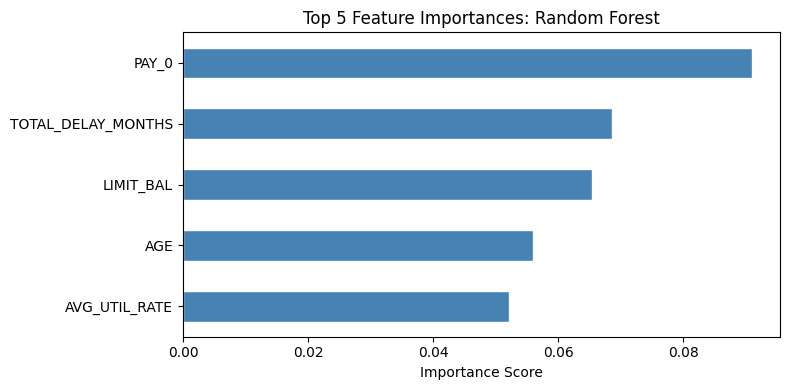


Top 5 features:
 PAY_0                 0.090916
TOTAL_DELAY_MONTHS    0.068663
LIMIT_BAL             0.065413
AGE                   0.055899
AVG_UTIL_RATE         0.052101
dtype: float64


In [11]:
#Cross Validationn
cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_scores=cross_val_score(lr, X_train_sc, y_train, cv=cv, scoring='roc_auc')
rf_scores=cross_val_score(rf, X_train_sc, y_train, cv=cv, scoring='roc_auc')

print("Logistic Regression CV AUC: {:.4f} ± {:.4f}".format(lr_scores.mean(), lr_scores.std()))
print("Random Forest CV AUC:{:.4f} ± {:.4f}".format(rf_scores.mean(), rf_scores.std()))

#Feature Impprtance(Random Forest)
feat_imp=pd.Series(rf.feature_importances_,index=X.columns)
top5_feats=feat_imp.sort_values(ascending=False).head(5)

plt.figure(figsize=(8, 4))
top5_feats.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 5 Feature Importances: Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\nTop 5 features:\n", top5_feats)

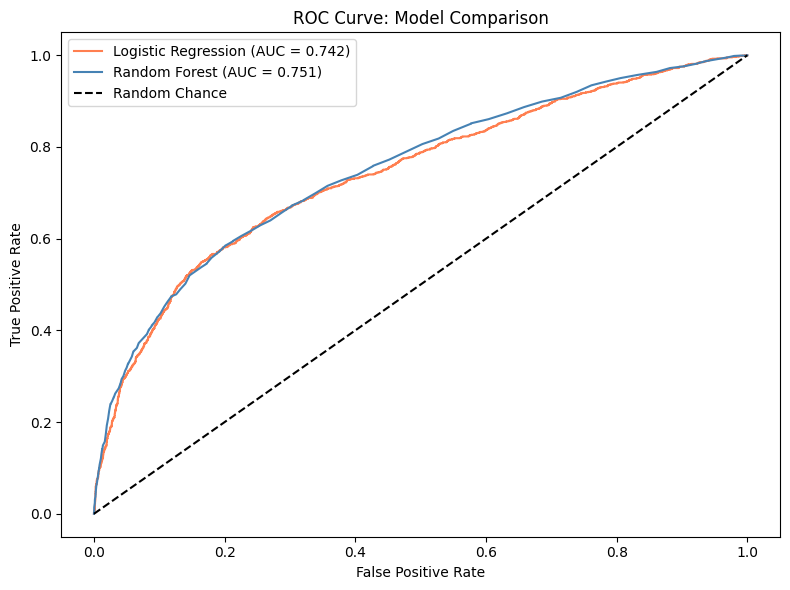

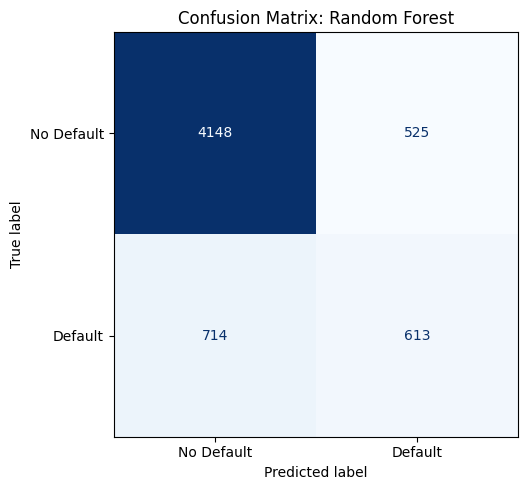

True Negatives  (correctly predicted no default): 4148
False Positives (flagged as default, actually ok): 525
False Negatives (missed actual defaulters):714
True Positives  (correctly caught defaulters):613


In [12]:
#ROC Curve
fpr_lr,tpr_lr, _=roc_curve(y_test, y_prob_lr)
fpr_rf,tpr_rf, _=roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = 0.742)', color='coral')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = 0.751)', color='steelblue')
plt.plot([0,1], [0,1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Model Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

#Confusion Matrix (Random Forest: best model)
cm=confusion_matrix(y_test, y_pred_rf)
disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])

fig, ax=plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix: Random Forest')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly predicted no default): {tn}")
print(f"False Positives (flagged as default, actually ok): {fp}")
print(f"False Negatives (missed actual defaulters):{fn}")
print(f"True Positives  (correctly caught defaulters):{tp}")

In [13]:
#SQL Queries
import sqlite3

#Loading dataframe into SQLite inmemory database
conn=sqlite3.connect(':memory:')
df.to_sql('credit', conn, index=False, if_exists='replace')

#Default rate by education level
q1=pd.read_sql("""
    SELECT
        EDUCATION,
        COUNT(*) as total_clients,
        SUM("default") as total_defaults,
        ROUND(AVG("default") * 100, 2) as default_rate_pct
    FROM credit
    GROUP BY EDUCATION
    ORDER BY EDUCATION
""", conn)
print("Default Rate by Education Level:")
print(q1.to_string(index=False))

#Average credit limit for defaulters vs non-defaulters
q2 = pd.read_sql("""
    SELECT
        "default" as defaulted,
        ROUND(AVG(LIMIT_BAL), 0) as avg_credit_limit,
        ROUND(AVG(AGE), 1) as avg_age,
        COUNT(*) as total_clients
    FROM credit
    GROUP BY "default"
""", conn)
print("\nQ2: Profile of Defaulters vs Non-Defaulters:")
print(q2.to_string(index=False))

#Top 5 most delayed client segments (by marriage + education)
q3 = pd.read_sql("""
    SELECT
        MARRIAGE,
        EDUCATION,
        ROUND(AVG(TOTAL_DELAY_MONTHS), 2) as avg_delay_months,
        ROUND(AVG("default") * 100, 2) as default_rate_pct,
        COUNT(*) as total_clients
    FROM credit
    GROUP BY MARRIAGE, EDUCATION
    HAVING total_clients > 100
    ORDER BY default_rate_pct DESC
    LIMIT 5
""", conn)
print("\nHighest Risk Segments (Marriage × Education):")
print(q3.to_string(index=False))

conn.close()

Default Rate by Education Level:
 EDUCATION  total_clients  total_defaults  default_rate_pct
         1          10585            2036             19.23
         2          14030            3330             23.73
         3           4917            1237             25.16
         4            468              33              7.05

Q2: Profile of Defaulters vs Non-Defaulters:
 defaulted  avg_credit_limit  avg_age  total_clients
         0          178100.0     35.4          23364
         1          130110.0     35.7           6636

Highest Risk Segments (Marriage × Education):
 MARRIAGE  EDUCATION  avg_delay_months  default_rate_pct  total_clients
        3          2              0.89             26.79            168
        1          3              1.04             26.35           2861
        1          2              0.90             24.35           6842
        2          3              0.91             23.68           1909
        2          2              0.96             23.0

Fairness by SEX
(1 = Male, 2 = Female)

SEX=1 | FPR: 0.127 | FNR: 0.542 | n=2402
SEX=2 | FPR: 0.103 | FNR: 0.535 | n=3598

Fairness by EDUCATION
(1=Grad, 2=University, 3=High School, 4=Other)

EDU=1 | FPR: 0.091 | FNR: 0.573 | n=2130
EDU=2 | FPR: 0.126 | FNR: 0.505 | n=2774
EDU=3 | FPR: 0.130 | FNR: 0.559 | n=1014
EDU=4 | FPR: 0.052 | FNR: 1.000 | n=82


/tmp/ipykernel_5762/2498637939.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sex_fpr=X_test_df.groupby('SEX').apply(false_positive_rate)
/tmp/ipykernel_5762/2498637939.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  edu_fpr=X_test_df.groupby('EDUCATION').apply(false_positive_rate)


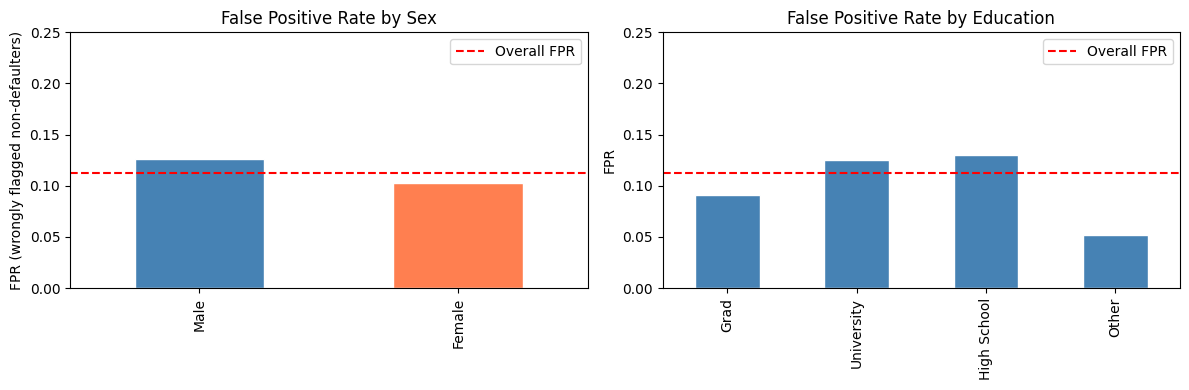

In [14]:
#Fairness Check

#Get predictions on test set (already have y_pred_rf, y_test)
X_test_df=X_test.copy()
X_test_df['true']=y_test.values
X_test_df['predicted']=y_pred_rf

def false_positive_rate(group):
    non_defaulters=group[group['true'] == 0]
    if len(non_defaulters) == 0:
        return None
    return (non_defaulters['predicted'] == 1).sum()/len(non_defaulters)

def false_negative_rate(group):
    defaulters=group[group['true']== 1]
    if len(defaulters)== 0:
        return None
    return (defaulters['predicted']== 0).sum()/len(defaulters)

#Fairness by SEX
print("Fairness by SEX")
print("(1 = Male, 2 = Female)\n")
for sex, group in X_test_df.groupby('SEX'):
    fpr = false_positive_rate(group)
    fnr = false_negative_rate(group)
    print(f"SEX={sex} | FPR: {fpr:.3f} | FNR: {fnr:.3f} | n={len(group)}")

#Fairness by EDUCATION
print("\nFairness by EDUCATION")
print("(1=Grad, 2=University, 3=High School, 4=Other)\n")
for edu, group in X_test_df.groupby('EDUCATION'):
    fpr = false_positive_rate(group)
    fnr = false_negative_rate(group)
    print(f"EDU={edu} | FPR: {fpr:.3f} | FNR: {fnr:.3f} | n={len(group)}")

#Visualise FPR disparity
fig, axes=plt.subplots(1, 2, figsize=(12, 4))

sex_fpr=X_test_df.groupby('SEX').apply(false_positive_rate)
sex_fpr.index=['Male', 'Female']
sex_fpr.plot(kind='bar', ax=axes[0], color=['steelblue','coral'], edgecolor='white')
axes[0].set_title('False Positive Rate by Sex')
axes[0].set_ylabel('FPR (wrongly flagged non-defaulters)')
axes[0].set_ylim(0, 0.25)
axes[0].axhline(525/4673, color='red', linestyle='--', label='Overall FPR')
axes[0].legend()

edu_fpr=X_test_df.groupby('EDUCATION').apply(false_positive_rate)
edu_fpr.index=['Grad', 'University', 'High School', 'Other']
edu_fpr.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('False Positive Rate by Education')
axes[1].set_ylabel('FPR')
axes[1].set_ylim(0, 0.25)
axes[1].axhline(525/4673, color='red', linestyle='--', label='Overall FPR')
axes[1].legend()

plt.tight_layout()
plt.savefig('fairness_check.png', dpi=150)
plt.show()

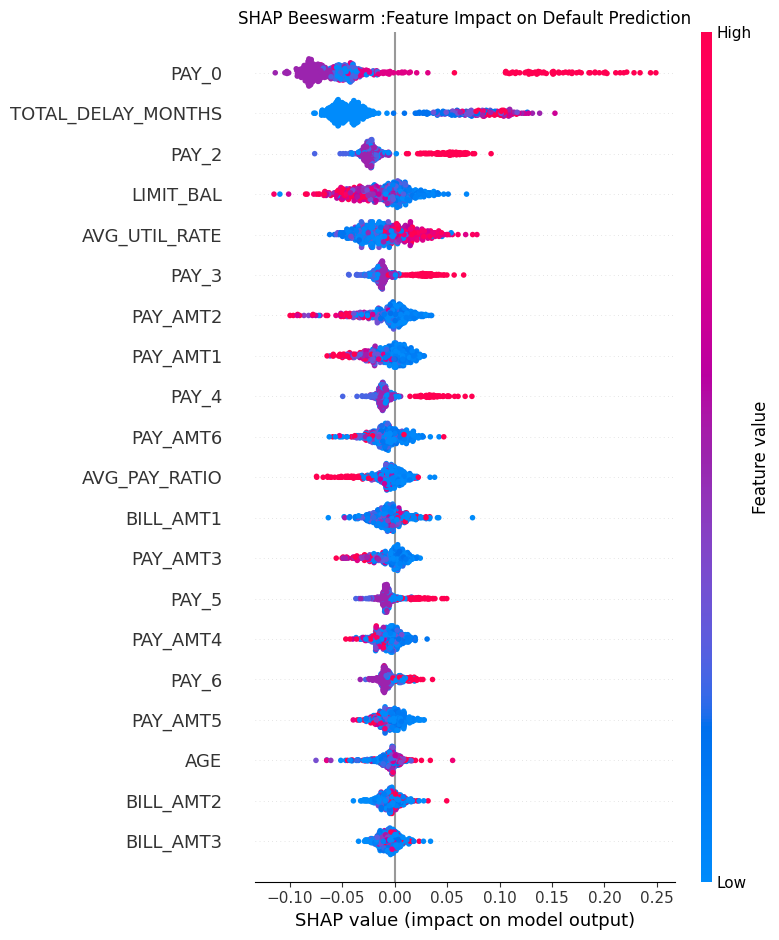

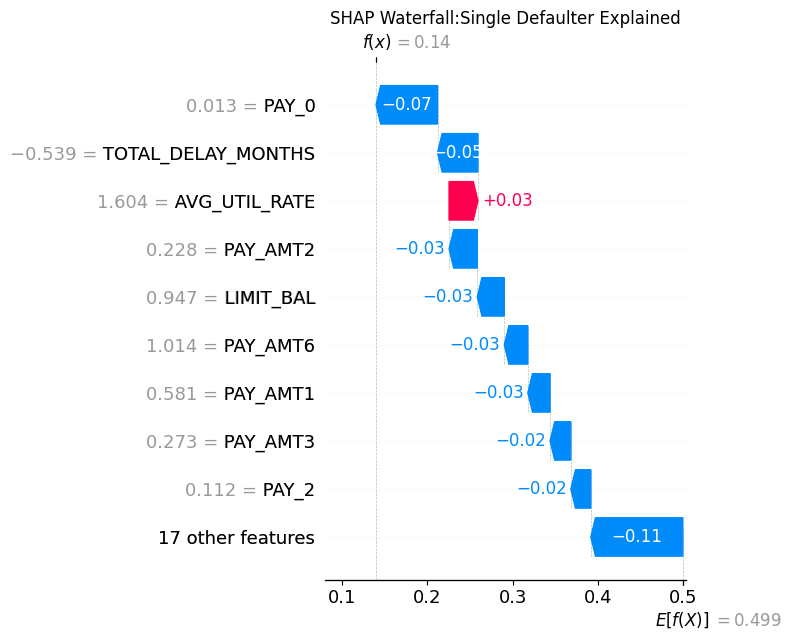

In [15]:
# SHAP

import shap
explainer=shap.TreeExplainer(rf)

#Take 10 samples from test set for waterfall, 500 for beeswarm
X_test_array = pd.DataFrame(X_test_sc, columns=X.columns)
shap_values = explainer.shap_values(X_test_array[:500])

#Beeswarm plot: overall feature impact
plt.figure()
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_array[:500],
    show=False
)
plt.title('SHAP Beeswarm :Feature Impact on Default Prediction')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

#Waterfall plot: single prediction explanation (first defaulter in test set)
defaulter_idx=y_test.reset_index(drop=True)[y_test.reset_index(drop=True)==1].index[0]
shap_explanation=explainer(X_test_array.iloc[[defaulter_idx]])

shap.plots.waterfall(shap_explanation[:, :, 1][0], show=False)
plt.title('SHAP Waterfall:Single Defaulter Explained')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

